# Improving Computer Vision Accuracy using Convolutions

지금까지 Deep Neural Network (DNN) 를 이용해서 패션 mnist 를 분류했다.  

In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten

I0000 00:00:1788238910.275729   71177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788238910.312917   71177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788238911.274596   71177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf
# TensorFlow가 GPU 메모리를 처음부터 크게 선점하지 않고, 필요한 만큼 점진적으로 사용하도록 설정
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
mnist = tf.keras.datasets.fashion_mnist

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
X_test.shape

(10000, 28, 28)

In [8]:
# 이미지 처리에서는 이미지를 그대로 사용함.

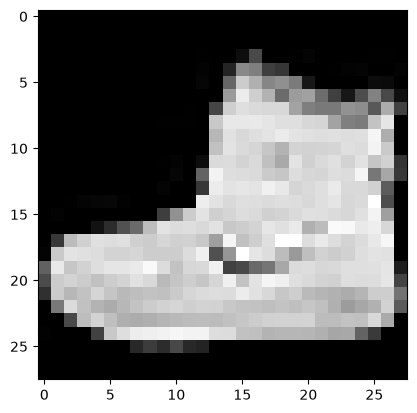

In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap='gray')
plt.show()

- image 데이터 표현

In [10]:
# gray scale
60000, 28, 28, 1

(60000, 28, 28, 1)

DNN에서는 정확도가, 트레이닝셋은 89% 정도이고 테스트셋으로는  87% 정도가 나왔다. 

이제 Convolutional Neural Networks 이용해서 정확도를 향상시켜본다.




In [11]:
from keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten
from tensorflow import keras

In [ ]:
def build_model(input_shape):  # (28, 28, 1)
    model = Sequential()
    model.add(keras.Input(shape = input_shape))
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation=keras.activations.relu ))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    model.add(Conv2D(filters=32, kernel_size=(3,3), activation=keras.activations.relu))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    # 여기까지는 이미지의 특징 파악, 이후 분류를 위해 ANN 실행
    model.add(Flatten()) # 벡터화
    model.add(Dense(128, keras.activations.relu))
    model.add(Dense(10, keras.activations.softmax))

    # model compile
    model.compile(optimizer=keras.optimizers.Adam(), 
                  loss= keras.losses.SparseCategoricalCrossentropy(),
                  metrics=[keras.metrics.SparseCategoricalAccuracy()])
    return model
    


In [13]:
model = build_model((28,28,1))

I0000 00:00:1788238913.061401   71177 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,922 (480.16 KB)

 Trainable params: 122,922 (480.16 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# NVIDIA GeForce GTX 1050 2G VRAM에서 tensorflow 2.21 버전 사용시 발생한 오류
# NVIDIA 오래된 모델을 사용할 경우 Tensorflow 최신버전 사용한 제한될 수 있음.
# InternalError: Graph execution error:
# ...

#   File "/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py", line 125, in wrapper

# Autotuning failed for HLO: %cudnn-conv-bias-activation.6 = (f32[4,64,26,26]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.17, %transpose, %arg3.1), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/conv2d_2_1/convolution" source_file="/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1221}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} with error: NOT_FOUND: No valid config found!
# 	 [[{{node StatefulPartitionedCall}}]] [Op:__inference_multi_step_on_iterator_1703]

In [16]:
#  NVIDIA GeForce GTX 1050 2G VRAM
# UDA/cuDNN 조합에서 GTX 1050의 Conv2D/cuDNN 실행 호환성 문제
# VRAM 부족보다는 TensorFlow 2.21.0 + 현재 CUDA/cuDNN 조합의 GPU convolution 호환 문제로 보는 것이 더 타당
# 즉, cuDNN이 Conv2D 연산에 사용할 수 있는 유효한 커널 구성을 찾지 못한 것이다. 
# 현재 TensorFlow 2.21.0 공식 빌드는 CUDA 12.5, cuDNN 9.3 기준인데, 
# 현재 uv 환경에는 CUDA 12.9 계열과 cuDNN 9.25가 설치되어 있다. 공식 빌드 조합과 차이가 있다.

# 확인방법
# uv pip show nvidia-cuda-runtime-cu12
# uv pip show nvidia-cudnn-cu12
# uv pip show tensorfow

# rm -rf .venv
# uv init --bare
# uv add "tensorflow[and-cuda]==2.20.0"  <-- 이것도 오류, NVIDIA GeForce GTX 1050
# uv add "tensorflow[and-cuda]==2.17.1"  <-- 여기서 학습이 됨, NVIDIA GeForce GTX 1050

# README.md 파일 참고해서 가상환경 셋팅하기

# uv run python -c "import tensorflow as tf; print(tf.__version__); print(tf.config.list_physical_devices('GPU'))"


In [ ]:
# 모델 이미 한 번 학습한 이후 다시 실행하면 이미 학습된 결과에 학습 또 실행. 주의.
history = model.fit(
  X_train, y_train, 
  epochs=20, 
  batch_size=1000,
  # validation_data=(X_test, y_test)
  validation_split=0.2
  )

Epoch 1/20


I0000 00:00:1788238912.365709   71354 service.cc:153] XLA service 0x7c1da80334f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788238912.365735   71354 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788238912.381401   71354 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788238912.494588   71354 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788238912.501082   71354 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1523__.30


 7/48 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.1625 - sparse_categorical_accuracy: 0.3206

I0000 00:00:1788238917.129571   71354 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 1.1051 - sparse_categorical_accuracy: 0.6464 - val_loss: 0.6240 - val_sparse_categorical_accuracy: 0.7647
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5670 - sparse_categorical_accuracy: 0.7890 - val_loss: 0.5096 - val_sparse_categorical_accuracy: 0.8153
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4740 - sparse_categorical_accuracy: 0.8295 - val_loss: 0.4457 - val_sparse_categorical_accuracy: 0.8454
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4278 - sparse_categorical_accuracy: 0.8481 - val_loss: 0.4145 - val_sparse_categorical_accuracy: 0.8557
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3938 - sparse_categorical_accuracy: 0.8627 - val_loss: 0.4005 - val_sparse_categorical_accuracy: 0.8584
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3768 - sparse_categorical_accuracy: 0.8671 - val_loss: 0.3713 - val_sparse_categorical_accuracy: 0.8702
Epoch 7/20
48/48 ━━━━

In [18]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3119 - sparse_categorical_accuracy: 0.8841


[0.31193581223487854, 0.8841000199317932]

## 학습결과 확인

In [19]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

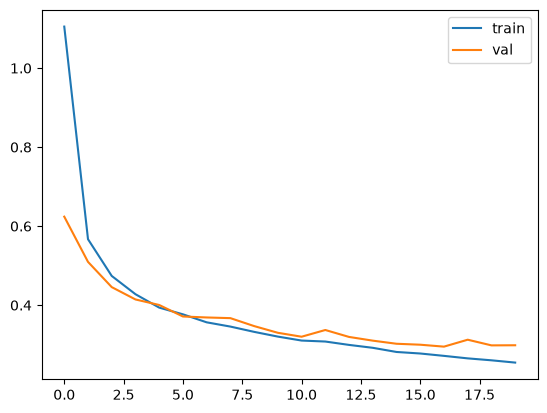

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()


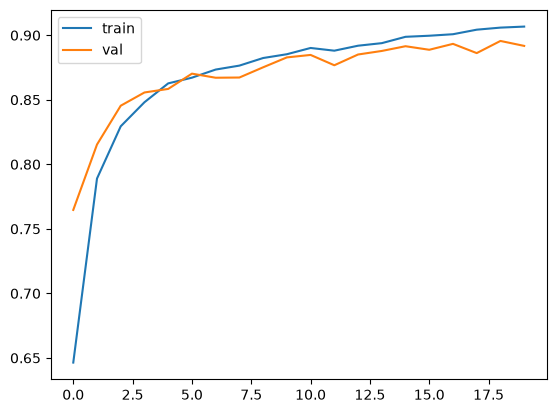

In [21]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.legend(['train', 'val'])
plt.show()

## 모델 평가

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [23]:
y_pred_pro = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
y_pred_pro

array([[1.4071955e-05, 6.1451164e-09, 1.0956715e-06, ..., 6.0270764e-03,
        1.2031853e-04, 9.8925859e-01],
       [5.2180467e-06, 1.2319459e-08, 9.9714488e-01, ..., 1.4275543e-15,
        2.8191293e-08, 6.7697597e-12],
       [2.6023756e-07, 9.9999785e-01, 2.8922535e-08, ..., 1.3868312e-13,
        3.4243339e-08, 3.3745895e-12],
       ...,
       [7.1930262e-05, 7.5703195e-09, 1.4361850e-04, ..., 7.4705490e-08,
        9.9893004e-01, 1.8256168e-09],
       [2.0215784e-06, 9.9963808e-01, 1.9901154e-06, ..., 7.9764645e-10,
        2.9184894e-06, 1.2263814e-07],
       [1.4133273e-03, 6.6539210e-06, 2.5243853e-04, ..., 1.2268857e-01,
        2.6255215e-02, 4.1764407e-04]], shape=(10000, 10), dtype=float32)

In [25]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.8841

In [26]:
# Fashion MNIST 클래스 이름
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 예측 label 이름으로 변환
predicted_labels = [class_names[i] for i in y_pred_labels]

In [27]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [28]:
import pandas as pd
df = pd.DataFrame(data=cm, columns=class_names)
df.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,743,0,17,29,5,0,198,0,8,0
1,0,972,0,21,3,0,3,0,1,0
2,8,1,808,12,51,0,119,0,1,0
3,6,7,7,904,20,0,54,0,2,0
4,0,2,52,39,778,0,129,0,0,0


<Axes: >

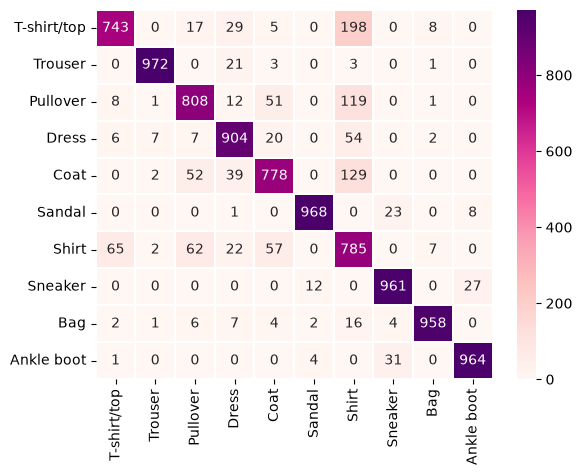

In [29]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df.columns,
          yticklabels=df.columns)

## EarlyStopping으로 다시 학습

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
# 새로운 초기 가중치로 처음부터 다시 학습
# del model
tf.keras.backend.clear_session()

model = build_model((28,28,1))

In [32]:
# callback, 함수
# EarlyStopping(monitor='val_loss', mode=validation 로스 최소, patience=loss 올라가는것을 몇번 참느냐?, 
#  restore_best_weights=True weight가 가장 좋았던 상태로 되돌리기 )
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

In [33]:
# patience=5의 의미
# Epoch 10 : val_loss = 0.30  ← 최고 성능
# Epoch 11 : 개선 없음        ← 1
# Epoch 12 : 개선 없음        ← 2
# Epoch 13 : 개선 없음        ← 3
# Epoch 14 : 개선 없음        ← 4
# Epoch 15 : 개선 없음        ← 5 → 중단

In [34]:
# 학습
history2 = model.fit(
  X_train, y_train, 
  epochs = 100, 
  validation_split=0.2, 
  callbacks=[early_stopping])

Epoch 1/100


I0000 00:00:1788238942.453175   71355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12469__.30


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.4925 - sparse_categorical_accuracy: 0.8195 - val_loss: 0.3580 - val_sparse_categorical_accuracy: 0.8698
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3286 - sparse_categorical_accuracy: 0.8802 - val_loss: 0.3155 - val_sparse_categorical_accuracy: 0.8863
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2867 - sparse_categorical_accuracy: 0.8939 - val_loss: 0.2920 - val_sparse_categorical_accuracy: 0.8932
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2531 - sparse_categorical_accuracy: 0.9075 - val_loss: 0.2690 - val_sparse_categorical_accuracy: 0.9033
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2306 - sparse_categorical_accuracy: 0.9149 - val_loss: 0.2705 - val_sparse_categorical_accuracy: 0.9020
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2097 - sparse_categorical_accuracy: 0.9219 - val_loss: 0.2657 - val_sparse_categorical_accuracy: 0.901

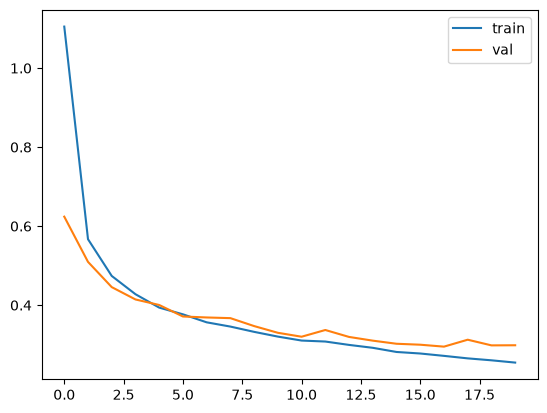

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

In [36]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.8841

In [37]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [38]:
import pandas as pd
df2 = pd.DataFrame(data=cm, columns=class_names)
df2.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,743,0,17,29,5,0,198,0,8,0
1,0,972,0,21,3,0,3,0,1,0
2,8,1,808,12,51,0,119,0,1,0
3,6,7,7,904,20,0,54,0,2,0
4,0,2,52,39,778,0,129,0,0,0


<Axes: >

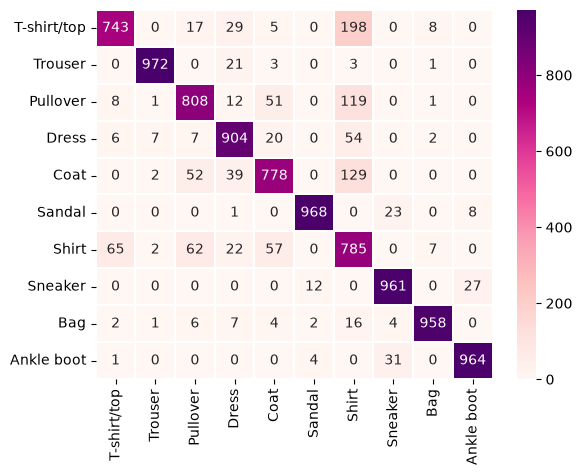

In [39]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df2.columns,
          yticklabels=df2.columns)

트레이닝셋은 97% , 테스트셋은 89% 까지 나온다.


에포크를 20까지 해보면, 트레이닝셋 정확도는 올라가지만 밸리데이션 정확도는 내려간다. 즉, 오버핏팅이 된다.







```
import tensorflow as tf
mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
training_images=training_images.reshape(60000, 28, 28, 1)
training_images=training_images / 255.0
test_images = test_images.reshape(10000, 28, 28, 1)
test_images=test_images/255.0
```
